In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
df = pd.read_csv('/kaggle/input/titanic/train_and_test2.csv')

# Remove rerundant columns 
for i in df.columns:
    if(len(df[i].unique()) == 1):
        df = df.drop(columns=i)

print(df.head())

   Passengerid   Age     Fare  Sex  sibsp  Parch  Pclass  Embarked  2urvived
0            1  22.0   7.2500    0      1      0       3       2.0         0
1            2  38.0  71.2833    1      1      0       1       0.0         1
2            3  26.0   7.9250    1      0      0       3       2.0         1
3            4  35.0  53.1000    1      1      0       1       2.0         1
4            5  35.0   8.0500    0      0      0       3       2.0         0


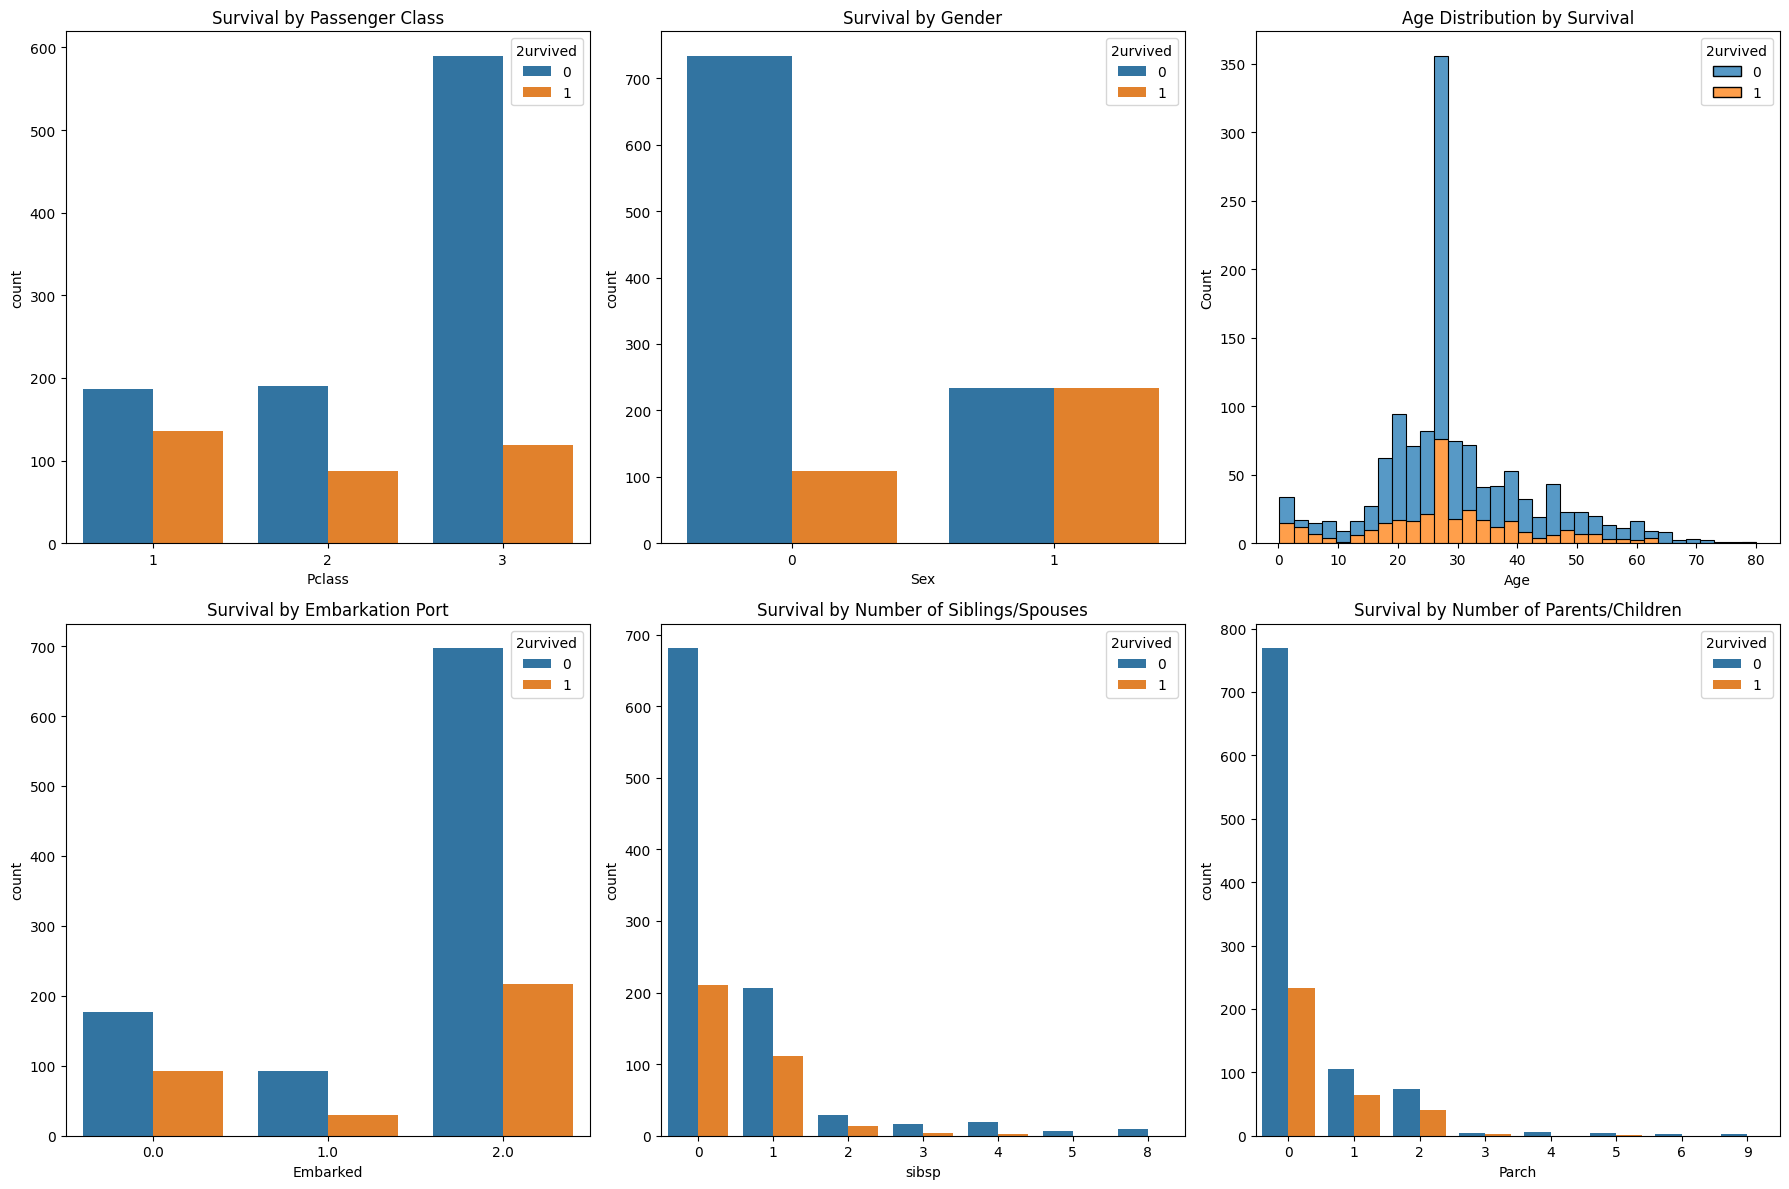

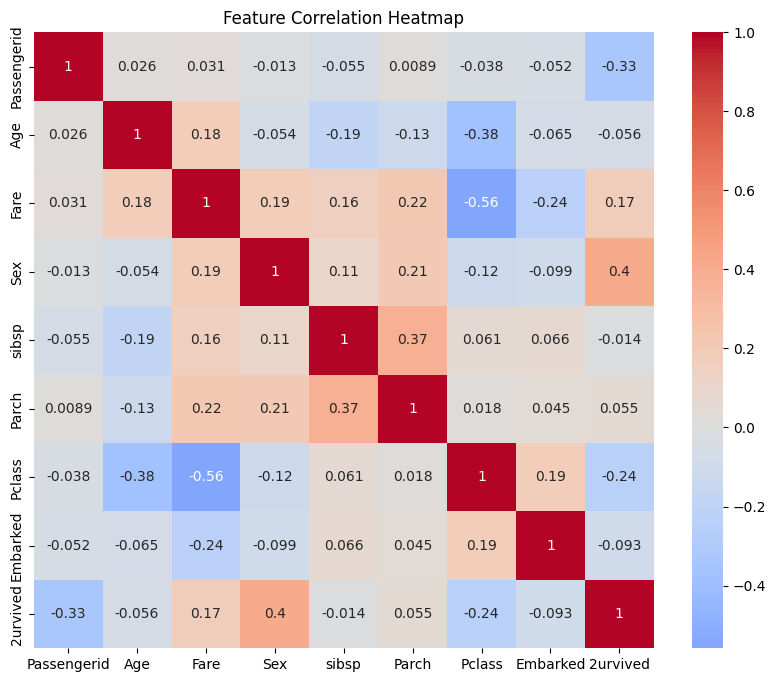

In [3]:
# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Survival by Class
sns.countplot(data=df, x='Pclass', hue='2urvived', ax=axes[0,0])
axes[0,0].set_title('Survival by Passenger Class')

# Plot 2: Survival by Sex
sns.countplot(data=df, x='Sex', hue='2urvived', ax=axes[0,1])
axes[0,1].set_title('Survival by Gender')

# Plot 3: Age distribution by survival
sns.histplot(data=df, x='Age', hue='2urvived', multiple='stack', ax=axes[0,2])
axes[0,2].set_title('Age Distribution by Survival')

# Plot 4: Survival by Embarkation Port
sns.countplot(data=df, x='Embarked', hue='2urvived', ax=axes[1,0])
axes[1,0].set_title('Survival by Embarkation Port')

# Plot 5: Survival by SibSp (Siblings/Spouses)
sns.countplot(data=df, x='sibsp', hue='2urvived', ax=axes[1,1])
axes[1,1].set_title('Survival by Number of Siblings/Spouses')

# Plot 6: Survival by Parch (Parents/Children)
sns.countplot(data=df, x='Parch', hue='2urvived', ax=axes[1,2])
axes[1,2].set_title('Survival by Number of Parents/Children')

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [4]:
# Create a copy for feature engineering

def engineer_features(df):
    df = df.copy()
    
    # Family size feature
    df['FamilySize'] = df['sibsp'] + df['Parch'] + 1
    
    # Is alone feature
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # Age groups
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                           labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])
    
    # Fare per person
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']
    
    return df

# Apply feature engineering
df = engineer_features(df)

print("🆕 Engineered Features:")
print(df[['FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson']].head())

🆕 Engineered Features:
   FamilySize  IsAlone AgeGroup  FarePerPerson
0           2        0    Adult        3.62500
1           2        0   Middle       35.64165
2           1        1    Adult        7.92500
3           2        0    Adult       26.55000
4           1        1    Adult        8.05000


In [5]:
print("🔍 Missing Values Data:")
print(df.isnull().sum())

# Handle missing values
def handle_missing_values(df):
    df = df.copy()
    
    # Age - fill with median based on Title and Pclass
    df['Age'] = df.groupby(['Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
    
    # Embarked - fill with mode
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    # Fare - fill with median based on Pclass
    df['Fare'] = df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
    
    return df

df = handle_missing_values(df)
X = df.drop(columns = ['Passengerid','2urvived'])
y = df['2urvived']

print("\n✅ After Handling Missing Values:")
print("Missing values:", df.isnull().sum().sum())

🔍 Missing Values Data:
Passengerid      0
Age              0
Fare             0
Sex              0
sibsp            0
Parch            0
Pclass           0
Embarked         2
2urvived         0
FamilySize       0
IsAlone          0
AgeGroup         0
FarePerPerson    0
dtype: int64

✅ After Handling Missing Values:
Missing values: 0


In [6]:
# Select features for modeling
features = ['Pclass', 'Sex', 'Age', 'sibsp', 'Parch', 'Fare', 'Embarked', 
            'FamilySize', 'IsAlone', 'FarePerPerson']

# Prepare training data
X = df[features]
y = df['2urvived']

# Split the data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


print("📊 Features for modeling:")
print(X.columns.tolist())

# One-hot encoding for categorical variables
categorical_features = ['Sex', 'Embarked']
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

# Ensure both train and test have same columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"\n📈 Final feature matrix shape: {X_train_encoded.shape}")


# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test_encoded.shape[0]} samples")

📊 Features for modeling:
['Pclass', 'Sex', 'Age', 'sibsp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'FarePerPerson']

📈 Final feature matrix shape: (916, 11)
Training set: 916 samples
Validation set: 197 samples
Test set: 196 samples


In [7]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Train and evaluate models
results = {}

print("🚀 Training and Evaluating Models...")
print("="*50)

for name, model in models.items():
    # Train the model
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
        y_proba = model.predict_proba(X_val_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate accuracy
    accuracy = accuracy_score(y_val, y_pred)
    results[name] = accuracy
    
    print(f"✅ {name:25} | Accuracy: {accuracy:.4f}")

# Compare model performance
print("\n🏆 Model Comparison:")
print("="*30)
for name, accuracy in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:25} | {accuracy:.4f}")

🚀 Training and Evaluating Models...
✅ Logistic Regression       | Accuracy: 0.7766
✅ K-Nearest Neighbors       | Accuracy: 0.7259
✅ Support Vector Machine    | Accuracy: 0.7259
✅ Random Forest             | Accuracy: 0.7563
✅ Gradient Boosting         | Accuracy: 0.7614

🏆 Model Comparison:
Logistic Regression       | 0.7766
Gradient Boosting         | 0.7614
Random Forest             | 0.7563
K-Nearest Neighbors       | 0.7259
Support Vector Machine    | 0.7259



🎯 Tuning Best Model: Logistic Regression
Using default parameters for this model

📋 Final Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       145
           1       0.63      0.37      0.46        52

    accuracy                           0.78       197
   macro avg       0.72      0.64      0.66       197
weighted avg       0.76      0.78      0.75       197



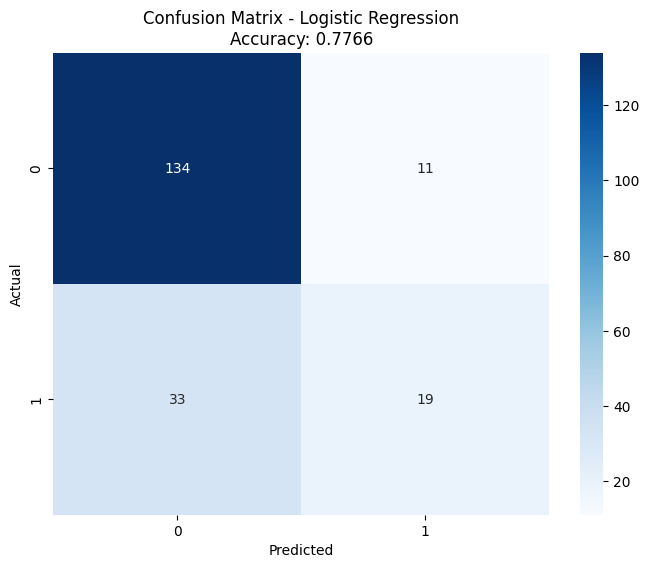

In [8]:
# Let's tune the best performing model
best_model_name = max(results, key=results.get)
print(f"\n🎯 Tuning Best Model: {best_model_name}")

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestClassifier(random_state=42)
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 4, 5]
    }
    base_model = GradientBoostingClassifier(random_state=42)
else:
    # For other models, use default
    print("Using default parameters for this model")
    tuned_model = models[best_model_name]
    tuned_model.fit(X_train, y_train) if best_model_name not in ['Logistic Regression', 'SVM'] else tuned_model.fit(X_train_scaled, y_train)

if best_model_name in ['Random Forest', 'Gradient Boosting']:
    grid_search = GridSearchCV(
        base_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1
    )
    
    # Fit on appropriate data
    if best_model_name in ['Logistic Regression', 'SVM']:
        grid_search.fit(X_train_scaled, y_train)
        best_params = grid_search.best_params_
        tuned_model = grid_search.best_estimator_
        y_pred_tuned = tuned_model.predict(X_val_scaled)
    else:
        grid_search.fit(X_train, y_train)
        best_params = grid_search.best_params_
        tuned_model = grid_search.best_estimator_
        y_pred_tuned = tuned_model.predict(X_val)
    
    tuned_accuracy = accuracy_score(y_val, y_pred_tuned)
    
    print(f"🎯 Best Parameters: {best_params}")
    print(f"🎯 Tuned Accuracy: {tuned_accuracy:.4f} (Improvement: {tuned_accuracy - results[best_model_name]:.4f})")
else:
    tuned_model = models[best_model_name]
    tuned_accuracy = results[best_model_name]

# Final evaluation
if best_model_name in ['Logistic Regression', 'SVM']:
    y_pred_final = tuned_model.predict(X_val_scaled)
else:
    y_pred_final = tuned_model.predict(X_val)

print(f"\n📋 Final Classification Report for {best_model_name}:")
print(classification_report(y_val, y_pred_final))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}\nAccuracy: {tuned_accuracy:.4f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


🔍 Permutation Importance:
          feature  importance_mean  importance_std
8           Sex_1         0.058883        0.020075
0          Pclass         0.045685        0.022814
6         IsAlone         0.012183        0.011396
3           Parch         0.007107        0.003367
1             Age         0.005076        0.007864
7   FarePerPerson         0.002538        0.008263
9    Embarked_1.0         0.002538        0.005201
10   Embarked_2.0         0.002538        0.002538
4            Fare        -0.000508        0.006979
5      FamilySize        -0.002030        0.006886


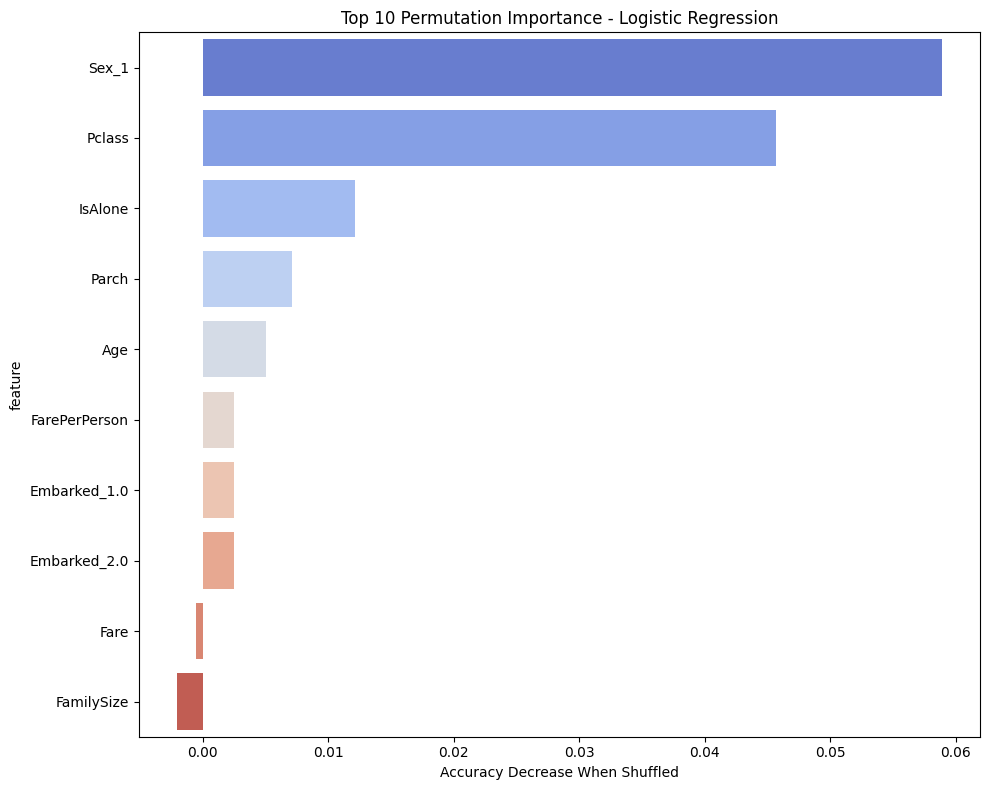

In [9]:
# Feature importance for tree-based models
if hasattr(tuned_model, 'feature_importances_'):
    print("🔍 Feature Importance Analysis:")
    feature_importance = pd.DataFrame({
        'feature': X_train_encoded.columns,
        'importance': tuned_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(feature_importance.head(10))
    
    # Plot top 10 features
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(10)
    sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 10 Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()

# Permutation importance for any model
from sklearn.inspection import permutation_importance

print("\n🔍 Permutation Importance:")
perm_importance = permutation_importance(
    tuned_model, 
    X_val_scaled if best_model_name in ['Logistic Regression', 'SVM'] else X_val,
    y_val, 
    n_repeats=10, 
    random_state=42
)

perm_df = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print(perm_df.head(10))

# Plot permutation importance
plt.figure(figsize=(10, 8))
top_perm = perm_df.head(10)
sns.barplot(data=top_perm, x='importance_mean', y='feature', palette='coolwarm')
plt.title(f'Top 10 Permutation Importance - {best_model_name}')
plt.xlabel('Accuracy Decrease When Shuffled')
plt.tight_layout()
plt.show()

In [10]:
# Make predictions on test set
if best_model_name in ['Logistic Regression', 'SVM']:
    test_predictions = tuned_model.predict(X_test_scaled)
else:
    test_predictions = tuned_model.predict(X_test_encoded)


print(f"🏆 Final Model: {best_model_name}")
print(f"📈 Validation Accuracy: {tuned_accuracy:.4f}")
print(f"👥 Test Predictions: {len(test_predictions)} passengers")
print(f"📊 Survival Rate in Predictions: {test_predictions.mean():.2%}")

🏆 Final Model: Logistic Regression
📈 Validation Accuracy: 0.7766
👥 Test Predictions: 196 passengers
📊 Survival Rate in Predictions: 19.90%
